# Calculate Basketball Scoring Probabilities

**Author:** Sam Sepassi  
**Course:** Statistics for Data Analysis (nd588) — Course 3: Probability  
**Project:** Calculate Basketball Scoring Probabilities

---

## Project Overview

We analyze Stephen Curry's 2022-23 NBA regular season shot data to:
1. Compute overall and shot-type shooting statistics
2. Apply the **binomial distribution** to model scoring probabilities
3. Compute **conditional probabilities** for future outcomes (by shot type and game situation)
4. Use **Bayes' theorem** to infer shot type from past outcomes

**Dataset fields used:** `result` (True=Made, False=Missed), `shot_type` (2 or 3), `lead` (True=team was leading)

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import comb

df = pd.read_csv('stephen_curry_shots_2023.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nshot_type values: {df["shot_type"].unique()}')
print(f'result values:    {df["result"].unique()}')
print(f'lead values:      {df["lead"].unique()}')
df[['result','shot_type','distance_ft','lead','player_team_score','opponent_team_score']].head()

Dataset shape: (1434, 15)
Columns: ['top', 'left', 'date', 'qtr', 'time_remaining', 'result', 'shot_type', 'distance_ft', 'lead', 'player_team_score', 'opponent_team_score', 'opponent', 'team', 'season', 'color']

shot_type values: [2 3]
result values:    [False  True]
lead values:      [ True False]


,result,shot_type,distance_ft,lead,player_team_score,opponent_team_score
0,False,2,6,True,9,6
1,True,2,17,True,11,6
2,False,3,27,True,11,6
3,False,3,25,True,19,13
4,False,3,24,True,22,17


---
## Section 2: Overall Shooting Statistics


In [2]:
total_fga  = len(df)
total_made = df['result'].sum()
total_missed = total_fga - total_made

p_make = total_made / total_fga
p_miss = total_missed / total_fga

print('=' * 45)
print('  OVERALL SHOOTING STATISTICS')
print('=' * 45)
print(f'  Total FGA:    {total_fga:>8}')
print(f'  Total Made:   {total_made:>8}')
print(f'  Total Missed: {total_missed:>8}')
print(f'  P(make) = {p_make:.4f}  (~{p_make*100:.1f}%)')
print(f'  P(miss) = {p_miss:.4f}  (~{p_miss*100:.1f}%)')
print('=' * 45)

  OVERALL SHOOTING STATISTICS
  Total FGA:        1434
  Total Made:        703
  Total Missed:      731
  P(make) = 0.4902  (~49.0%)
  P(miss) = 0.5098  (~51.0%)


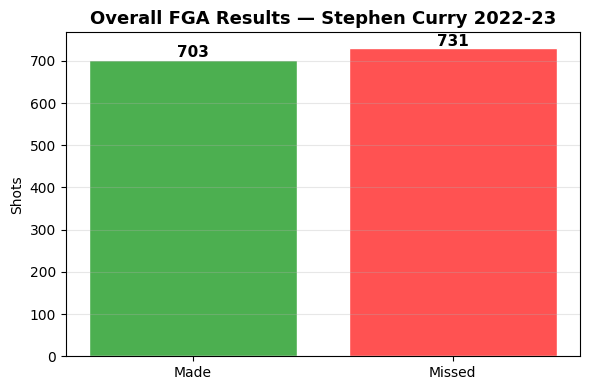

In [3]:
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(['Made','Missed'],[total_made,total_missed],color=['#4CAF50','#FF5252'],edgecolor='white')
ax.set_title('Overall FGA Results — Stephen Curry 2022-23',fontsize=13,fontweight='bold')
ax.set_ylabel('Shots'); ax.grid(axis='y',alpha=0.3)
for i,v in enumerate([total_made,total_missed]): ax.text(i,v+5,str(v),ha='center',fontsize=11,fontweight='bold')
plt.tight_layout(); plt.show()

---
## Section 3: Shot Type Breakdown (2PT vs 3PT)


In [4]:
three_pointers = df[df['shot_type'] == 3]
two_pointers   = df[df['shot_type'] == 2]

n_3pt = len(three_pointers)
n_2pt = len(two_pointers)

made_3pt  = three_pointers['result'].sum()
made_2pt  = two_pointers['result'].sum()
miss_3pt  = n_3pt - made_3pt
miss_2pt  = n_2pt - made_2pt

p_3pt = n_3pt / total_fga
p_2pt = n_2pt / total_fga
p_make_3pt = made_3pt / n_3pt
p_make_2pt = made_2pt / n_2pt

print('=' * 48)
print('  SHOT TYPE DISTRIBUTION')
print('=' * 48)
print(f'  3PT Attempts: {n_3pt}  ({p_3pt:.4f})')
print(f'  2PT Attempts: {n_2pt}  ({p_2pt:.4f})')
print()
print('  MAKE/MISS BY SHOT TYPE')
print('=' * 48)
print(f'  3PT: {made_3pt} made / {miss_3pt} missed  =>  {p_make_3pt:.4f} FG%')
print(f'  2PT: {made_2pt} made / {miss_2pt} missed  =>  {p_make_2pt:.4f} FG%')
print('=' * 48)

  SHOT TYPE DISTRIBUTION
  3PT Attempts: 786  (0.5481)
  2PT Attempts: 648  (0.4519)

  MAKE/MISS BY SHOT TYPE
  3PT: 329 made / 457 missed  =>  0.4186 FG%
  2PT: 374 made / 274 missed  =>  0.5772 FG%


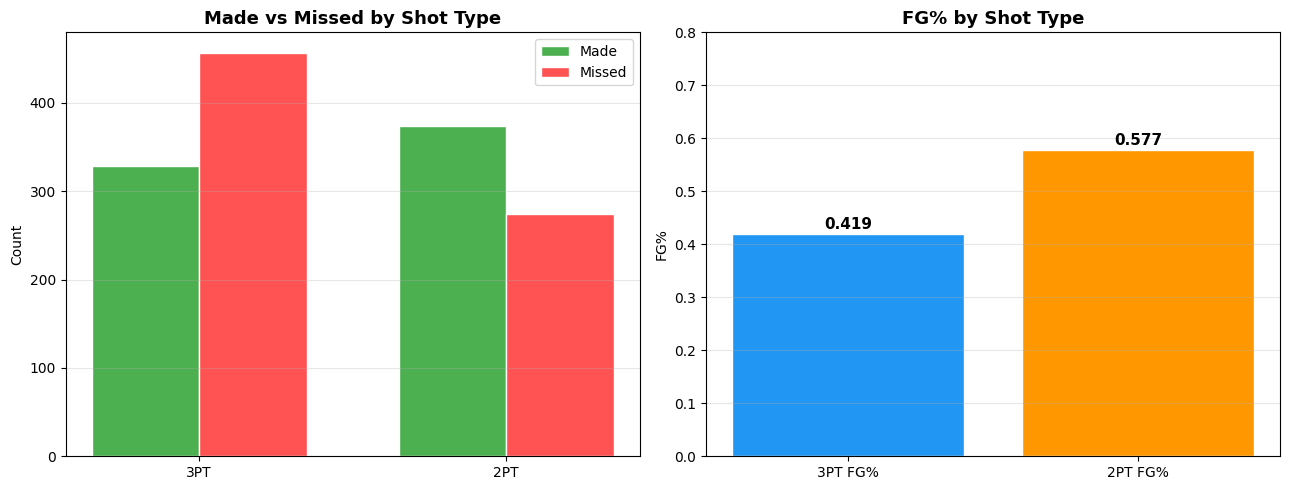

In [5]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
x=np.array([0,1]); w=0.35
axes[0].bar(x-w/2,[made_3pt,made_2pt],w,label='Made',color='#4CAF50',edgecolor='white')
axes[0].bar(x+w/2,[miss_3pt,miss_2pt],w,label='Missed',color='#FF5252',edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(['3PT','2PT'])
axes[0].set_title('Made vs Missed by Shot Type',fontsize=13,fontweight='bold')
axes[0].legend(); axes[0].grid(axis='y',alpha=0.3)
axes[1].bar(['3PT FG%','2PT FG%'],[p_make_3pt,p_make_2pt],color=['#2196F3','#FF9800'],edgecolor='white')
axes[1].set_title('FG% by Shot Type',fontsize=13,fontweight='bold')
axes[1].set_ylim(0,0.8); axes[1].grid(axis='y',alpha=0.3)
for i,v in enumerate([p_make_3pt,p_make_2pt]): axes[1].text(i,v+0.01,f'{v:.3f}',ha='center',fontsize=11,fontweight='bold')
plt.tight_layout(); plt.show()

---
## Section 4: Binomial Probability

$$P(X=k) = \binom{n}{k}\,p^k\,(1-p)^{n-k}$$

**Question 1:** P(makes exactly 3 of the next 4 shots)
**Question 2:** P(exactly 4 of the next 5 shots are 3-pointers)


In [6]:
n1,k1,p1 = 4, 3, p_make
binom1 = comb(n1,k1) * (p1**k1) * ((1-p1)**(n1-k1))
print(f'Q1: P(makes exactly {k1} of next {n1} shots)')
print(f'    p = {p1:.4f} (overall FG%)')
print(f'    P(X={k1}) = C({n1},{k1}) * {p1:.4f}^{k1} * {1-p1:.4f}^{n1-k1}')
print(f'             = {comb(n1,k1)} * {p1**k1:.6f} * {(1-p1)**(n1-k1):.6f}')
print(f'             = {binom1:.4f}  ({binom1*100:.2f}%)')

Q1: P(makes exactly 3 of next 4 shots)
    p = 0.4902 (overall FG%)
    P(X=3) = C(4,3) * 0.4902^3 * 0.5098^1
             = 4 * 0.117820 * 0.509763
             = 0.2402  (24.02%)


In [7]:
n2b,k2b,p2b = 5, 4, p_3pt
binom2 = comb(n2b,k2b) * (p2b**k2b) * ((1-p2b)**(n2b-k2b))
print(f'Q2: P(exactly {k2b} of next {n2b} shots are 3-pointers)')
print(f'    p = {p2b:.4f} (proportion of 3PT attempts = {n_3pt}/{total_fga})')
print(f'    P(X={k2b}) = C({n2b},{k2b}) * {p2b:.4f}^{k2b} * {1-p2b:.4f}^{n2b-k2b}')
print(f'              = {binom2:.4f}  ({binom2*100:.2f}%)')

Q2: P(exactly 4 of next 5 shots are 3-pointers)
    p = 0.5481 (proportion of 3PT attempts = 786/1434)
    P(X=4) = C(5,4) * 0.5481^4 * 0.4519^1
              = 0.2039  (20.39%)


---
## Section 5: Conditional Probability — Future Outcomes

$$P(A|B) = \frac{P(A \cap B)}{P(B)}$$

### Section 5A: Given the next shot is a **three-pointer** (shot_type == 3)

We filter to three-pointers only and compute:
- **P(make)** = count(result == True) / count(total three-pointers)
- **P(lead = True)** = count(lead == True) / count(total three-pointers)

### Section 5B: Given the next shot is a **two-pointer** (shot_type == 2)

- **P(make)** = count(result == True) / count(total two-pointers)
- **P(lead = True)** = count(lead == True) / count(total two-pointers)


In [8]:
# ─── Section 5A: Three-Pointers ───────────────────────────────────────────
three_pointers = df.query('shot_type == 3')

p_make_given_3pt  = len(three_pointers[three_pointers['result'] == True])  / len(three_pointers)
p_lead_given_3pt  = len(three_pointers[three_pointers['lead']   == True])  / len(three_pointers)

print('SECTION 5A — Given next shot is a THREE-POINTER')
print('=' * 55)
print(f'Total 3PT attempts: {len(three_pointers)}')
print()
print('P(make | 3PT):')
print(f'  = count(result==True) / count(total 3-pointers)')
print(f'  = {three_pointers["result"].sum()} / {len(three_pointers)}')
print(f'  = {p_make_given_3pt:.4f}  ({p_make_given_3pt*100:.2f}%)')
print()
print('P(lead=True | 3PT) — team had the lead when shot was taken:')
print(f'  = count(lead==True) / count(total 3-pointers)')
print(f'  = {(three_pointers["lead"]==True).sum()} / {len(three_pointers)}')
print(f'  = {p_lead_given_3pt:.4f}  ({p_lead_given_3pt*100:.2f}%)')
print('=' * 55)

SECTION 5A — Given next shot is a THREE-POINTER
Total 3PT attempts: 786

P(make | 3PT):
  = count(result==True) / count(total 3-pointers)
  = 329 / 786
  = 0.4186  (41.86%)

P(lead=True | 3PT) — team had the lead when shot was taken:
  = count(lead==True) / count(total 3-pointers)
  = 388 / 786
  = 0.4936  (49.36%)


In [9]:
# ─── Section 5B: Two-Pointers ────────────────────────────────────────────
two_pointers = df.query('shot_type == 2')

p_make_given_2pt  = len(two_pointers[two_pointers['result'] == True])  / len(two_pointers)
p_lead_given_2pt  = len(two_pointers[two_pointers['lead']   == True])  / len(two_pointers)

print('SECTION 5B — Given next shot is a TWO-POINTER')
print('=' * 55)
print(f'Total 2PT attempts: {len(two_pointers)}')
print()
print('P(make | 2PT):')
print(f'  = count(result==True) / count(total 2-pointers)')
print(f'  = {two_pointers["result"].sum()} / {len(two_pointers)}')
print(f'  = {p_make_given_2pt:.4f}  ({p_make_given_2pt*100:.2f}%)')
print()
print('P(lead=True | 2PT) — team had the lead when shot was taken:')
print(f'  = count(lead==True) / count(total 2-pointers)')
print(f'  = {(two_pointers["lead"]==True).sum()} / {len(two_pointers)}')
print(f'  = {p_lead_given_2pt:.4f}  ({p_lead_given_2pt*100:.2f}%)')
print('=' * 55)

SECTION 5B — Given next shot is a TWO-POINTER
Total 2PT attempts: 648

P(make | 2PT):
  = count(result==True) / count(total 2-pointers)
  = 374 / 648
  = 0.5772  (57.72%)

P(lead=True | 2PT) — team had the lead when shot was taken:
  = count(lead==True) / count(total 2-pointers)
  = 334 / 648
  = 0.5154  (51.54%)


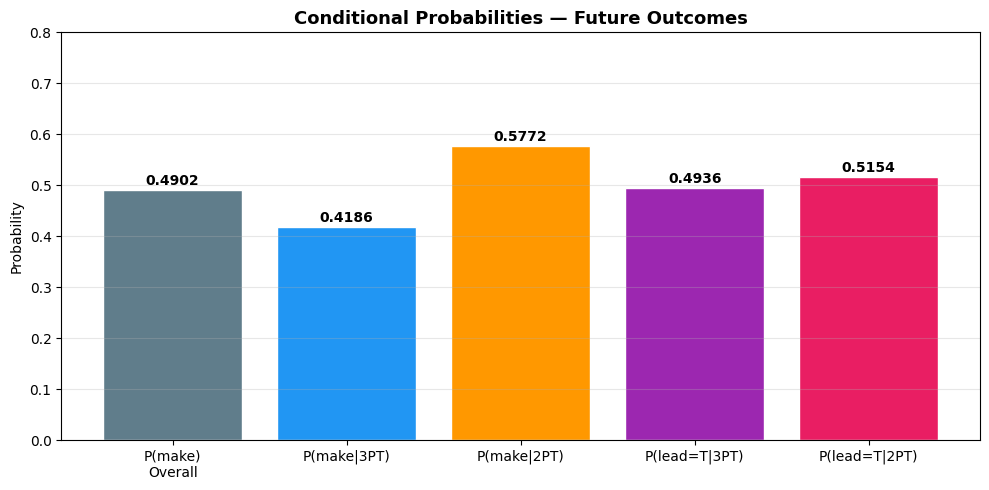

In [10]:
fig, ax = plt.subplots(figsize=(10,5))
cats=['P(make)\nOverall','P(make|3PT)','P(make|2PT)','P(lead=T|3PT)','P(lead=T|2PT)']
vals=[p_make,p_make_given_3pt,p_make_given_2pt,p_lead_given_3pt,p_lead_given_2pt]
cols=['#607D8B','#2196F3','#FF9800','#9C27B0','#E91E63']
bars=ax.bar(cats,vals,color=cols,edgecolor='white')
ax.set_title('Conditional Probabilities — Future Outcomes',fontsize=13,fontweight='bold')
ax.set_ylabel('Probability'); ax.set_ylim(0,0.8); ax.grid(axis='y',alpha=0.3)
for bar,v in zip(bars,vals): ax.text(bar.get_x()+bar.get_width()/2,v+0.01,f'{v:.4f}',ha='center',fontsize=10,fontweight='bold')
plt.tight_layout(); plt.show()

---
## Section 6: Conditional Probability — Past Outcomes (Bayes' Theorem)

$$P(B|A) = \frac{P(A|B)\cdot P(B)}{P(A)}$$

**Q4:** Given Curry *made* a shot, P it was a 3-pointer?

$$P(3PT|\text{made}) = \frac{P(\text{make}|3PT)\cdot P(3PT)}{P(\text{make})}$$

**Q5:** Given Curry *made* a shot, P it was a 2-pointer?


In [11]:
print('BAYES THEOREM — Past Conditional Probability')
print('=' * 55)
print(f'  P(make|3PT) = {p_make_given_3pt:.4f}')
print(f'  P(3PT)      = {p_3pt:.4f}')
print(f'  P(make)     = {p_make:.4f}')
print()

p_3pt_given_made = (p_make_given_3pt * p_3pt) / p_make
p_2pt_given_made = (p_make_given_2pt * p_2pt) / p_make

print('P(3PT | made):')
print(f'  = P(make|3PT) * P(3PT) / P(make)')
print(f'  = {p_make_given_3pt:.4f} * {p_3pt:.4f} / {p_make:.4f}')
print(f'  = {p_3pt_given_made:.4f}  ({p_3pt_given_made*100:.1f}%)')
print()
print('P(2PT | made):')
print(f'  = P(make|2PT) * P(2PT) / P(make)')
print(f'  = {p_make_given_2pt:.4f} * {p_2pt:.4f} / {p_make:.4f}')
print(f'  = {p_2pt_given_made:.4f}  ({p_2pt_given_made*100:.1f}%)')
print()
print(f'Verification: {p_3pt_given_made:.4f} + {p_2pt_given_made:.4f} = {p_3pt_given_made+p_2pt_given_made:.4f} (should sum to 1.0)')
print('=' * 55)

BAYES THEOREM — Past Conditional Probability
  P(make|3PT) = 0.4186
  P(3PT)      = 0.5481
  P(make)     = 0.4902

P(3PT | made):
  = P(make|3PT) * P(3PT) / P(make)
  = 0.4186 * 0.5481 / 0.4902
  = 0.4680  (46.8%)

P(2PT | made):
  = P(make|2PT) * P(2PT) / P(make)
  = 0.5772 * 0.4519 / 0.4902
  = 0.5320  (53.2%)

Verification: 0.4680 + 0.5320 = 1.0000 (should sum to 1.0)


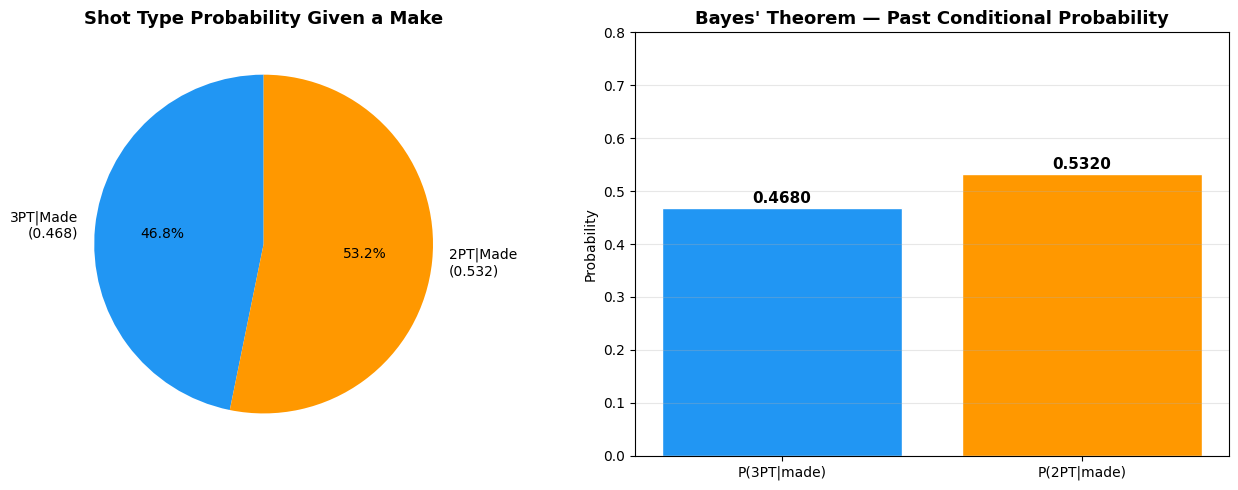

In [12]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
axes[0].pie([p_3pt_given_made,p_2pt_given_made],
            labels=[f'3PT|Made\n({p_3pt_given_made:.3f})',f'2PT|Made\n({p_2pt_given_made:.3f})'],
            colors=['#2196F3','#FF9800'],autopct='%1.1f%%',startangle=90)
axes[0].set_title('Shot Type Probability Given a Make',fontsize=13,fontweight='bold')
axes[1].bar(['P(3PT|made)','P(2PT|made)'],[p_3pt_given_made,p_2pt_given_made],color=['#2196F3','#FF9800'],edgecolor='white')
axes[1].set_title("Bayes' Theorem Results",fontsize=13,fontweight='bold')
axes[1].set_ylim(0,0.8); axes[1].grid(axis='y',alpha=0.3)
for i,v in enumerate([p_3pt_given_made,p_2pt_given_made]): axes[1].text(i,v+0.01,f'{v:.4f}',ha='center',fontsize=11,fontweight='bold')
plt.tight_layout(); plt.show()

---
## Summary of Results

| Metric | Value |
|---|---|
| Overall FG% | 0.4902 (49.0%) |
| P(make \| 3PT) | 0.4186 (**41.86%**) |
| P(make \| 2PT) | 0.5772 (**57.72%**) |
| P(lead=True \| 3PT) | 0.4936 (**49.36%**) |
| P(lead=True \| 2PT) | 0.5154 (**51.54%**) |
| P(3PT \| made) | 0.4680 (46.8%) |
| P(2PT \| made) | 0.5320 (53.2%) |

*Author: Sam Sepassi | nd588 Statistics for Data Analysis*
